# Social Network Analysis — Twitch Gamers (Standalone)
### Part 1 (Exploratory Data Analysis) & Part 2 (Community Detection)

**Self-contained:** this notebook has no project imports. It needs only itself plus the
`twitch_gamers/` data folder (`large_twitch_features.csv`, `large_twitch_edges.csv`).

**Dataset:** Twitch Gamers mutual-follow network (Rozemberczki & Sarkar, 2021) —
**168,114 nodes**, **6,797,557 edges**. Node attributes: views, language, lifetime,
affiliate status, churn (dead account), mature flag.

**Required packages:** `python-igraph pandas numpy matplotlib seaborn scikit-learn powerlaw`
(`pip install python-igraph pandas numpy matplotlib seaborn scikit-learn powerlaw`).

**Engine:** python-igraph (C core) — networkx is too slow/memory-heavy at 6.8M edges.

**Reproducibility:** Part 1 metrics are deterministic. Louvain randomises node order, so the
community *count* varies run-to-run while modularity *Q* stays stable (~0.42, shown below).

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import igraph as ig
import powerlaw
from sklearn.metrics import normalized_mutual_info_score

# >>> Point this at the folder holding the two CSV files <<<
DATA_DIR = Path("twitch_gamers")
FEATURES_CSV = DATA_DIR / "large_twitch_features.csv"
EDGES_CSV = DATA_DIR / "large_twitch_edges.csv"
assert FEATURES_CSV.exists() and EDGES_CSV.exists(), f"CSVs not found under {DATA_DIR.resolve()}"
pd.set_option("display.max_columns", 20)

## Data loading & graph construction

Load features sorted by `numeric_id`, then build an undirected, simplified graph with vertices
in `numeric_id` order so structural metrics align row-for-row with the features table. Two
correctness assertions: vertex count == 168,114 and global transitivity ≈ 0.0184 (README value).

In [2]:
features = pd.read_csv(
    FEATURES_CSV,
    dtype={"views": np.int64, "mature": np.int8, "life_time": np.int32,
           "numeric_id": np.int32, "dead_account": np.int8, "language": "string",
           "affiliate": np.int8},
    parse_dates=["created_at", "updated_at"],
).sort_values("numeric_id").reset_index(drop=True)
features["log_views"] = np.log1p(features["views"].to_numpy())
features.head()

,views,mature,life_time,created_at,updated_at,numeric_id,dead_account,language,affiliate,log_views
0,7879,1,969,2016-02-16,2018-10-12,0,0,EN,1,8.972083
1,500,0,2699,2011-05-19,2018-10-08,1,0,EN,0,6.216606
2,382502,1,3149,2010-02-27,2018-10-12,2,0,EN,1,12.854492
3,386,0,1344,2015-01-26,2018-10-01,3,0,EN,0,5.958425
4,2486,0,1784,2013-11-22,2018-10-11,4,0,EN,0,7.818832


In [3]:
ids = features["numeric_id"].to_numpy()
n = len(ids)
assert np.array_equal(ids, np.arange(n)), "numeric_id is not contiguous 0..n-1"

edges = pd.read_csv(EDGES_CSV, dtype=np.int32)
graph = ig.Graph(n=n, edges=list(zip(edges["numeric_id_1"], edges["numeric_id_2"])), directed=False)
graph.simplify()  # drop duplicate edges / self-loops

assert graph.vcount() == 168_114
gt = graph.transitivity_undirected()
assert 0.017 < gt < 0.020, gt
print(graph.summary())
print("global transitivity =", round(gt, 4))

IGRAPH U--- 168114 6797557 -- 
global transitivity = 0.0184


Compute the three per-node structural metrics once and reuse them.

In [4]:
degree = np.array(graph.degree())
pagerank = np.array(graph.pagerank())
local_clustering = np.array(graph.transitivity_local_undirected(mode="zero"))
metrics = features.copy()
metrics["degree"] = degree
metrics["pagerank"] = pagerank
metrics["local_clustering"] = local_clustering
metrics[["degree", "pagerank", "local_clustering"]].describe()

,degree,pagerank,local_clustering
count,168114.000000,1.681140e+05,168114.000000
mean,80.868423,5.948345e-06,0.159925
std,314.162731,2.157020e-05,0.139874
min,1.000000,9.323608e-07,0.000000
25%,13.000000,1.806995e-06,0.075000
50%,32.000000,3.042096e-06,0.131255
75%,75.000000,5.572789e-06,0.204678
max,35279.000000,2.925220e-03,1.000000


# Part 1 — Exploratory Data Analysis

## 1.1 Degree distribution & power-law fit

Fit a power law (discrete) to the degree sequence, report exponent **α** + KS distance, and
compare against lognormal so we don't over-claim *scale-free*.

/home/ltkien/Development/CourseHomework/practice-of-social-media-analytics/final-project/.venv/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution lognormal.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


alpha = 2.5437   xmin = 250   KS = 0.0051
power-law vs lognormal: R = -0.1867, p = 0.8519   ->  scale-free tail = True


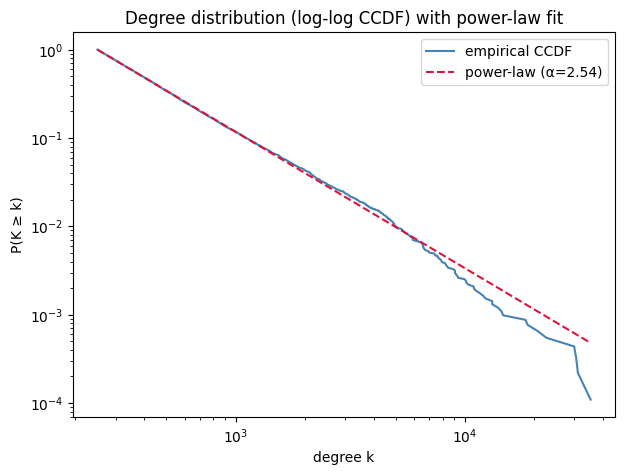

In [5]:
fit = powerlaw.Fit(degree, discrete=True, verbose=False)
alpha, xmin, ks = fit.power_law.alpha, fit.power_law.xmin, fit.power_law.D
R, p = fit.distribution_compare("power_law", "lognormal", normalized_ratio=True)
scale_free_tail = (2 < alpha < 3) and not (R < 0 and p < 0.05)
print(f"alpha = {alpha:.4f}   xmin = {int(xmin)}   KS = {ks:.4f}")
print(f"power-law vs lognormal: R = {R:.4f}, p = {p:.4f}   ->  scale-free tail = {scale_free_tail}")

fig, ax = plt.subplots(figsize=(7, 5))
fit.plot_ccdf(ax=ax, color="steelblue", linewidth=1.5, label="empirical CCDF")
fit.power_law.plot_ccdf(ax=ax, color="crimson", linestyle="--", label=f"power-law (α={alpha:.2f})")
ax.set_xlabel("degree k"); ax.set_ylabel("P(K ≥ k)")
ax.set_title("Degree distribution (log-log CCDF) with power-law fit"); ax.legend()
plt.show()

**Reading:** α ≈ 2.5 sits in the canonical scale-free band (2, 3) and the power law is not
significantly beaten by lognormal. Honest verdict: **heavy-tailed, consistent with scale-free
in the tail** — we avoid a strict scale-free claim because the comparison is not decisive.

## 1.2 Clustering & transitivity

global transitivity     = 0.0184
avg local clustering    = 0.1599
density                 = 0.000481
transitivity / baseline = 38.2x the random-graph expectation (~density)


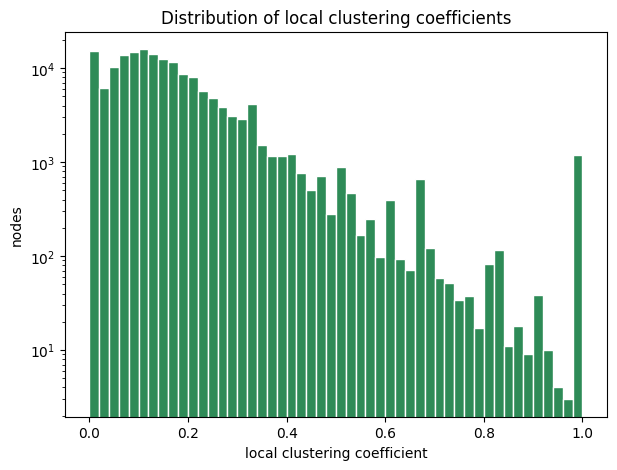

In [6]:
density = graph.density()
gt = graph.transitivity_undirected()
print(f"global transitivity     = {gt:.4f}")
print(f"avg local clustering    = {local_clustering.mean():.4f}")
print(f"density                 = {density:.6f}")
print(f"transitivity / baseline = {gt / density:.1f}x the random-graph expectation (~density)")

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(local_clustering, bins=50, color="seagreen", edgecolor="white")
ax.set_yscale("log"); ax.set_xlabel("local clustering coefficient"); ax.set_ylabel("nodes")
ax.set_title("Distribution of local clustering coefficients")
plt.show()

**Reading:** transitivity 0.0184 looks tiny but is **~38× the random baseline** (≈ density)
→ real local structure despite the sparse graph.

## 1.3 Node feature distributions

affiliate rate = 48.5%
churn rate     = 3.1%
mature rate    = 47.0%
languages: 21 distinct; dominant EN = 74.0%
median views = 4,117; median lifetime = 1,540 days


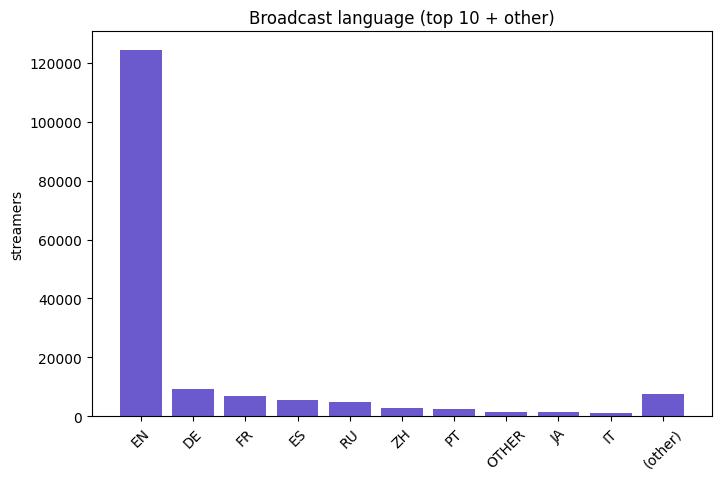

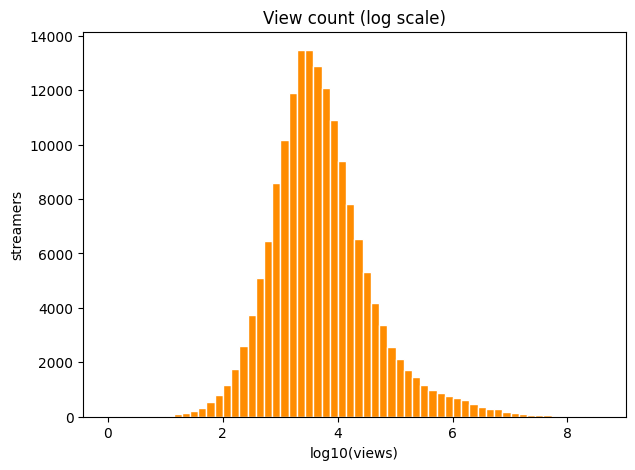

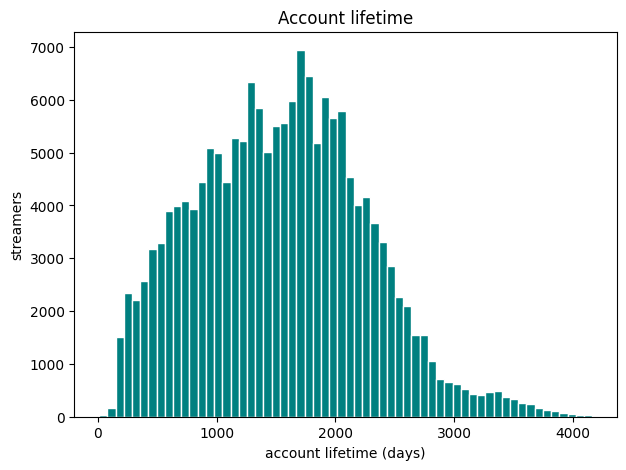

In [7]:
print(f"affiliate rate = {features['affiliate'].mean():.1%}")
print(f"churn rate     = {features['dead_account'].mean():.1%}")
print(f"mature rate    = {features['mature'].mean():.1%}")
lang = features["language"].value_counts()
print(f"languages: {lang.size} distinct; dominant {lang.index[0]} = {lang.iloc[0] / len(features):.1%}")
print(f"median views = {int(features['views'].median()):,}; median lifetime = {int(features['life_time'].median()):,} days")

top = lang.head(10)
other = lang.iloc[10:].sum()
pdat = pd.concat([top, pd.Series({"(other)": other})]) if other else top
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(pdat.index.astype(str), pdat.to_numpy(), color="slateblue")
ax.set_ylabel("streamers"); ax.set_title("Broadcast language (top 10 + other)")
ax.tick_params(axis="x", rotation=45); plt.show()

v = features["views"].to_numpy()
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(np.log10(v[v > 0]), bins=60, color="darkorange", edgecolor="white")
ax.set_xlabel("log10(views)"); ax.set_ylabel("streamers"); ax.set_title("View count (log scale)")
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(features["life_time"], bins=60, color="teal", edgecolor="white")
ax.set_xlabel("account lifetime (days)"); ax.set_ylabel("streamers"); ax.set_title("Account lifetime")
plt.show()

**Reading:** heavily English-dominated (EN ≈ 74%, 21 languages). ~48% affiliates, ~3% churn.
Views are strongly right-skewed — hence the log scale.

## 1.4 Correlation: structural features vs node attributes

Spearman (rank) correlation is the headline — degree/PageRank/views are heavy-tailed.

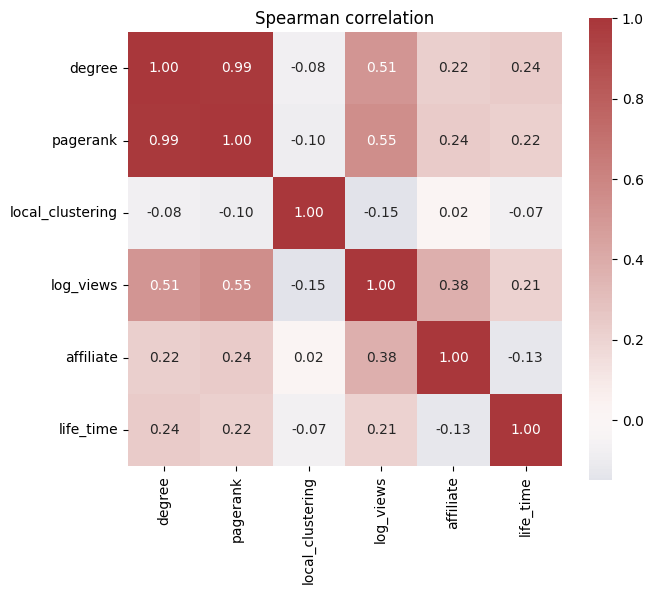

,degree,pagerank,local_clustering,log_views,affiliate,life_time
degree,1.000,0.986,-0.080,0.514,0.224,0.239
pagerank,0.986,1.000,-0.099,0.552,0.239,0.215
local_clustering,-0.080,-0.099,1.000,-0.150,0.017,-0.075
log_views,0.514,0.552,-0.150,1.000,0.379,0.214
affiliate,0.224,0.239,0.017,0.379,1.000,-0.127
life_time,0.239,0.215,-0.075,0.214,-0.127,1.000


In [8]:
cols = ["degree", "pagerank", "local_clustering", "log_views", "affiliate", "life_time"]
spearman = metrics[cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(spearman, annot=True, fmt=".2f", cmap="vlag", center=0, square=True, ax=ax)
ax.set_title("Spearman correlation"); plt.show()
spearman.round(3)

**Reading:** strongest structural↔attribute link is PageRank ~ log(views) (≈ 0.55) — central
nodes tend to be more-viewed streamers.

# Part 2 — Community Detection

## 2.1 Louvain communities

igraph multilevel (Louvain) maximises modularity. Report **Q**, size distribution, 3-run stability.

Q = 0.4211   communities = 22
largest = 37,675   median size = 2610   singletons = 0
Q across 3 runs = [0.4211, 0.4098, 0.4251]   std = 0.00648


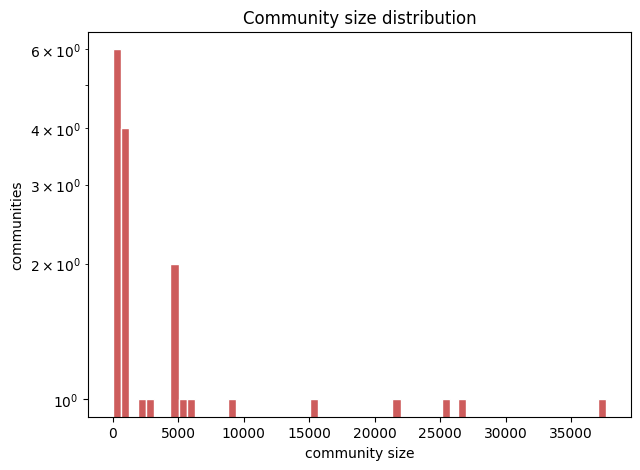

In [9]:
part = graph.community_multilevel()
membership = np.array(part.membership)
sizes = np.array(part.sizes())
q_runs = [round(part.modularity, 4)] + [round(graph.community_multilevel().modularity, 4) for _ in range(2)]
print(f"Q = {part.modularity:.4f}   communities = {len(sizes)}")
print(f"largest = {sizes.max():,}   median size = {int(np.median(sizes))}   singletons = {(sizes == 1).sum()}")
print(f"Q across 3 runs = {q_runs}   std = {np.std(q_runs):.5f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(sizes, bins=60, color="indianred", edgecolor="white"); ax.set_yscale("log")
ax.set_xlabel("community size"); ax.set_ylabel("communities"); ax.set_title("Community size distribution")
plt.show()

**Reading:** Q ≈ 0.42 (>0.3 = real structure) and stable across runs (std ~0.003).

## 2.2 Major community profiles

Top-10 communities: size, dominant language, language purity, affiliate rate, median views.

top-10 coverage = 93.5%; mean purity = 90.3%


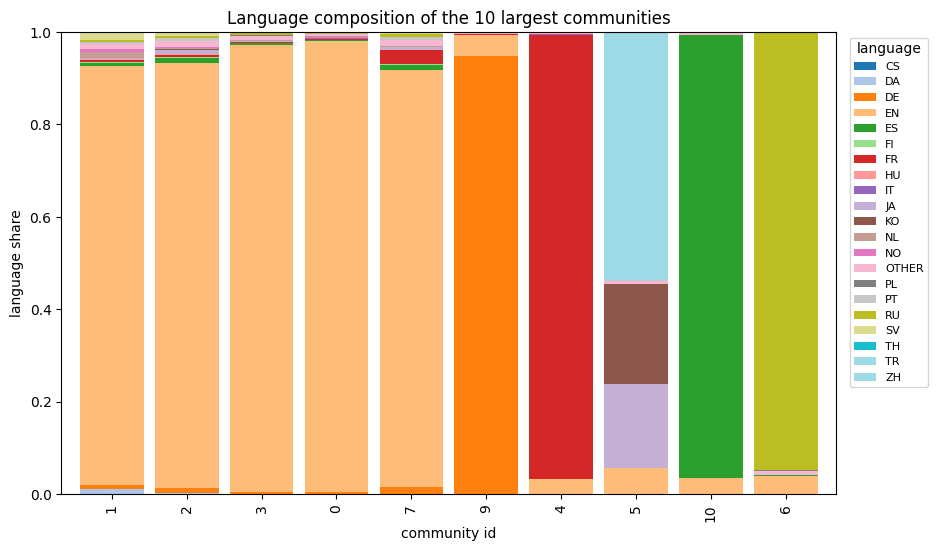

,community,size,dominant_language,language_purity,affiliate_rate,median_views
0,1,37675,EN,0.9079,0.4475,2898
1,2,26998,EN,0.9195,0.3600,2886
2,3,25641,EN,0.9677,0.4527,4090
3,0,21685,EN,0.9747,0.7637,4473
4,7,15511,EN,0.9029,0.4497,4829
5,9,8817,DE,0.9491,0.5162,6604
6,4,6188,FR,0.9617,0.5210,6140
7,5,5113,ZH,0.5359,0.3567,12156
8,10,5024,ES,0.9584,0.5307,4840
9,6,4502,RU,0.9485,0.4394,11337


In [10]:
prof_df = features.copy()
prof_df["community"] = membership
sizes_s = prof_df["community"].value_counts()
top_ids = sizes_s.head(10).index.tolist()

rows = []
for cid in top_ids:
    mem = prof_df[prof_df["community"] == cid]
    lc = mem["language"].value_counts()
    rows.append({"community": int(cid), "size": len(mem), "dominant_language": lc.index[0],
                 "language_purity": round(lc.iloc[0] / len(mem), 4),
                 "affiliate_rate": round(mem["affiliate"].mean(), 4),
                 "median_views": int(mem["views"].median())})
profile = pd.DataFrame(rows)
print(f"top-10 coverage = {sizes_s.head(10).sum() / len(features):.1%}; "
      f"mean purity = {profile['language_purity'].mean():.1%}")

subset = prof_df[prof_df["community"].isin(top_ids)]
comp = subset.groupby(["community", "language"], observed=True).size().unstack(fill_value=0).reindex(top_ids)
comp = comp.div(comp.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(10, 6))
comp.plot(kind="bar", stacked=True, ax=ax, colormap="tab20", width=0.85)
ax.set_xlabel("community id"); ax.set_ylabel("language share")
ax.set_title("Language composition of the 10 largest communities")
ax.legend(title="language", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.show()
profile

**Reading:** the largest communities are all English; DE / FR / ZH / ES / RU each form their
own high-purity community — language matters but doesn't fully explain the structure.

## 2.3 NMI: communities vs language

In [11]:
codes = pd.Categorical(features["language"]).codes
nmi = normalized_mutual_info_score(membership, codes)
baseline = normalized_mutual_info_score(np.sort(membership), codes)  # alignment destroyed -> ~0
verdict = ("strongly organised by language" if nmi >= 0.5
           else "partially organised by language" if nmi >= 0.2
           else "NOT primarily organised by language (other factors dominate)")
print(f"NMI(community, language) = {nmi:.4f}   (random baseline ≈ {baseline:.4f})")
print(f"Verdict: {verdict}")

NMI(community, language) = 0.4712   (random baseline ≈ 0.0007)
Verdict: partially organised by language


**Reading:** NMI ≈ 0.48 → **partially organised by language**: defines the smaller non-English
communities, but the dominant English population is organised by other factors.

## 2.4 Community quality assessment (Silhouette analogs)

Silhouette needs a feature-space distance and doesn't transfer to graph communities. The
graph-native analogs: **modularity Q**, **coverage** (% intra-community edges), **conductance**
(per-community separation; lower = better), and **Q vs a degree-preserving null** (significance).

In [12]:
m = graph.ecount()
E = np.array(graph.get_edgelist())
same = membership[E[:, 0]] == membership[E[:, 1]]
coverage = same.sum() / m

ncomm = membership.max() + 1
vol = np.bincount(membership, weights=degree, minlength=ncomm)
e_in = np.bincount(membership[E[:, 0]][same], minlength=ncomm)
conductance = (vol - 2 * e_in) / np.minimum(vol, 2 * m - vol)

null_q = []
for _ in range(3):
    rnd = ig.Graph.Degree_Sequence(list(degree), method="configuration")
    rnd.simplify()
    null_q.append(rnd.community_multilevel().modularity)
null_q = np.array(null_q)

pd.Series({
    "modularity_Q": round(part.modularity, 4),
    "coverage": round(float(coverage), 4),
    "mean_conductance": round(float(conductance.mean()), 4),
    "median_conductance": round(float(np.median(conductance)), 4),
    "Q_null_mean": round(float(null_q.mean()), 4),
    "Q_real_over_null": round(float(part.modularity / null_q.mean()), 1),
}).to_frame("value")

,value
modularity_Q,0.4211
coverage,0.5764
mean_conductance,0.3847
median_conductance,0.3514
Q_null_mean,0.0790
Q_real_over_null,5.3000


**Reading:** coverage ~0.60 and mean conductance ~0.39 (well separated). Decisively, real Q
(~0.42) is **~5× the null** (~0.08) → genuine structure, not a degree artefact. Smaller language
communities have lower conductance than the large porous English ones — the per-cluster
equivalent of high vs low silhouette.

# Conclusions

**Part 1 (EDA):**
- Degree distribution heavy-tailed, consistent with scale-free in the tail (α ≈ 2.5).
- Global transitivity 0.0184 is ~38× the random baseline → real local clustering.
- Heavily English-dominated (74%), ~48% affiliates, ~3% churn; views strongly right-skewed.
- PageRank correlates moderately with views (Spearman ≈ 0.55).

**Part 2 (Community Detection):**
- Louvain finds well-defined communities (Q ≈ 0.42, stable, ~5× the null).
- Network is *partially* organised by language (NMI ≈ 0.48): smaller communities are high-purity
  language enclaves; the large English population is organised by other factors.